### Reaction-Diffusion Simulation of Turing

This notebook demonstrates pattern formation in a reaction–diffusion system.

The model illustrates how spatial patterns such as spots or stripes can
emerge from homogeneous initial conditions through diffusion-driven instability.


Reaction–diffusion systems describe the dynamics of interacting chemical
or biological substances that diffuse in space.

Such systems can generate spatial patterns known as Turing patterns.
These mechanisms are believed to explain biological pattern formation
such as animal coat markings.

Reaction–Diffusion Equations

- ∂u/∂t = Du∇²u + f(u,v)
- ∂v/∂t = Dv∇²v + g(u,v)

- u : activator
- v : inhibitor
- Du : diffusion coefficient of u
- Dv : diffusion coefficient of v

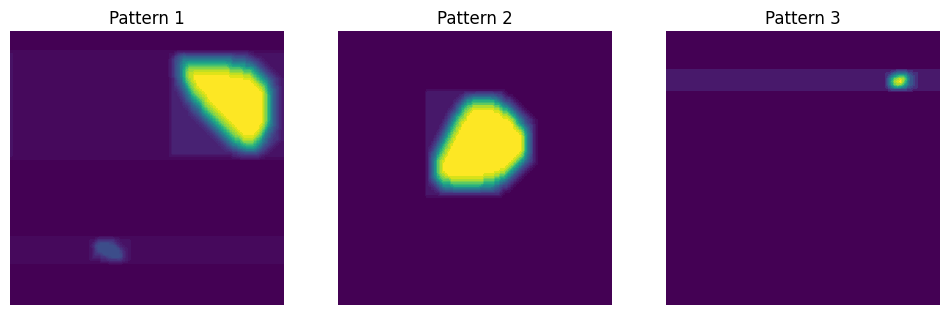

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def simulate(F, k, steps=10000):

    size = 100
    Du = 0.16
    Dv = 0.08

    u = np.ones((size, size))
    v = np.zeros((size, size))

    u += 0.01 * np.random.randn(size, size)
    v += 0.01 * np.random.randn(size, size)

    for _ in range(steps):

        lap_u = (
            np.roll(u,1,0) + np.roll(u,-1,0) +
            np.roll(u,1,1) + np.roll(u,-1,1) - 4*u
        )

        lap_v = (
            np.roll(v,1,0) + np.roll(v,-1,0) +
            np.roll(v,1,1) + np.roll(v,-1,1) - 4*v
        )

        uvv = u * v * v

        u += Du * lap_u - uvv + F * (1 - u)
        v += Dv * lap_v + uvv - (F + k) * v

    return u


pattern1 = simulate(0.035, 0.065)
pattern2 = simulate(0.04, 0.06)
pattern3 = simulate(0.022, 0.051)


fig, axs = plt.subplots(1,3,figsize=(12,4))

axs[0].imshow(pattern1)
axs[0].set_title("Pattern 1")

axs[1].imshow(pattern2)
axs[1].set_title("Pattern 2")

axs[2].imshow(pattern3)
axs[2].set_title("Pattern 3")

for ax in axs:
    ax.axis("off")

plt.show()

### Discussion
The simulations demonstrate that spatial patterns emerge from
initial random perturbations due to the interaction between
reaction kinetics and diffusion.

Different parameter values lead to qualitatively different
patterns such as spots or stripe-like structures.

These results illustrate the principle of diffusion-driven
instability proposed by Turing.


### Conclusion
This notebook shows how simple reaction–diffusion equations
can generate complex spatial patterns.

The emergence of ordered structures from random initial
conditions highlights a fundamental mechanism of biological
pattern formation.


### Parameter Exploration
To further investigate the effect of parameters,
we performed a parameter sweep over F and k.

This experiment visualizes how spatial patterns
change across different regions of parameter space.


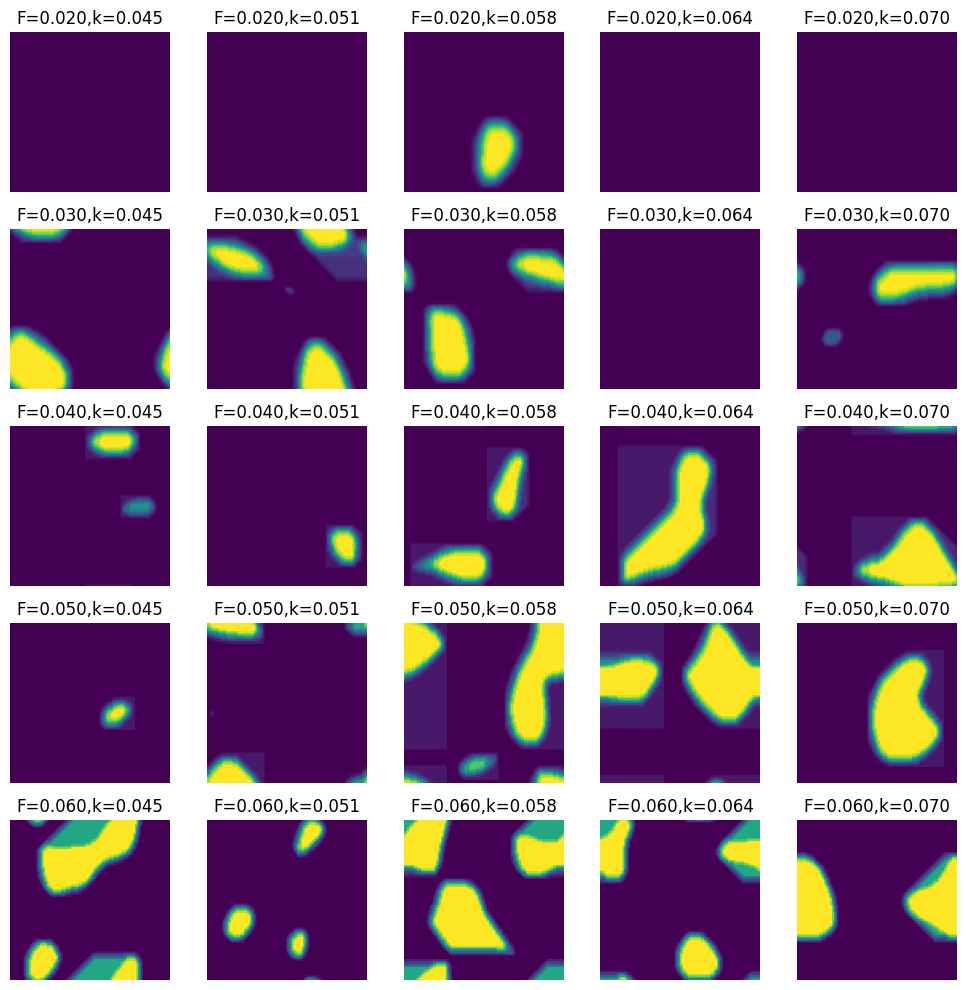

In [24]:
F_values = np.linspace(0.02,0.06,5)
k_values = np.linspace(0.045,0.07,5)

fig,axs = plt.subplots(len(F_values),len(k_values),figsize=(10,10))

for i,F in enumerate(F_values):
    for j,k in enumerate(k_values):

        pattern = simulate(F,k,steps=5000)

        axs[i,j].imshow(pattern)
        axs[i,j].set_title(f"F={F:.3f},k={k:.3f}")
        axs[i,j].axis("off")

plt.tight_layout()
plt.show()

### Conclusion
The parameter sweep reveals that pattern formation
is highly sensitive to parameter values.

Certain regions produce spot-like structures,
while others generate stripe-like patterns.